In [1]:
import gzip
import os
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dna_features_viewer import GraphicFeature, GraphicRecord
from Bio import SeqIO

cwd = os.getcwd()
if cwd.endswith('Halocins'):
    os.chdir('../..')
    cwd = os.getcwd()

from src.tree.itol_annotation import itol_labels

In [2]:
sns.set_palette('colorblind')
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.8)
plt.rcParams['font.family'] = 'Helvetica'

palette = sns.color_palette().as_hex()

data_folder = Path('data/')
assert data_folder.is_dir()

amp_db_folder = data_folder / 'amp_db'
assert amp_db_folder.is_dir()

halocins_folder = amp_db_folder / 'Halocins'
assert halocins_folder.is_dir()

halh4_folder = halocins_folder / 'Halocin_H4'
assert halh4_folder.is_dir()

halh4_out = Path('data/outputs/amp_db/Halocins/Halocin_H4')


In [3]:
gtdb_metadata = pd.read_csv(halh4_out / 'Halocin_H4_gtdb_metadata.csv', index_col='assembly_accession')

In [4]:
halh4_hits = pd.read_csv(halh4_folder / 'Halocin_H4_dataset_curated.csv', index_col='id')
halh4_hits['normalized_bitscore'] = (100 * halh4_hits['bits'] / halh4_hits.loc['WP_014732703.1@GCF_000306765.2', 'bits']).round(2)
halh4_hits.head()

,assembly_accession,protein_id,evalue,bits,tstart,tend,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,uniprot_id,normalized_bitscore
id,,,,,,,,,,,,,,,
WP_014732703.1@GCF_000306765.2,GCF_000306765.2,WP_014732703.1,7.295000e-233,723,1,359,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Haloferax,Haloferax mediterranei,Q48236,100.00
WP_241433888.1@GCF_000337535.1,GCF_000337535.1,WP_241433888.1,2.720000e-100,340,48,347,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrialba,Natrialba aegyptia,NaN,47.03
WP_008458115.1@GCF_000337175.1,GCF_000337175.1,WP_008458115.1,2.408000e-93,320,1,276,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema gari,L9YSX7,44.26
WP_161605605.1@GCF_000337135.1,GCF_000337135.1,WP_161605605.1,1.911000e-42,172,6,156,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrialba,Natrialba chahannaoensis,NaN,23.79
WP_155396796.1@GCF_000970305.1,GCF_000970305.1,WP_155396796.1,1.735000e-28,130,69,300,Archaea,Halobacteriota,Methanosarcinia,Methanosarcinales,Methanosarcinaceae,Methanosarcina,Methanosarcina barkeri A,A0A0E3SN68,17.98


In [5]:
halh4_hits['domain'].value_counts()

Archaea     18
Bacteria     4
Name: domain, dtype: int64

In [89]:
halh4_hits[halh4_hits['domain'] == 'Bacteria']

,assembly_accession,protein_id,evalue,bits,tstart,tend,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,uniprot_id,normalized_bitscore
id,,,,,,,,,,,,,,,
WP_076157611.1@GCF_001955925.1,GCF_001955925.1,WP_076157611.1,4.309000e-28,129,47,313,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus sp001955925,A0A1R1GAQ2,17.84
WP_123067460.1@GCF_003719335.1,GCF_003719335.1,WP_123067460.1,3.336000e-11,78,78,319,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus amylolyticus D,A0A5M9X370,10.79
WP_132280169.1@GCF_004339095.1,GCF_004339095.1,WP_132280169.1,7.936000e-11,76,71,278,Bacteria,Bacillota A,Clostridia,Lachnospirales,DSM-24629,Natranaerovirga,Natranaerovirga hydrolytica,A0A4R1MYC7,10.51
WP_175383825.1@GCF_013359905.1,GCF_013359905.1,WP_175383825.1,1.059000e-10,76,78,278,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus taichungensis,NaN,10.51


In [93]:
halh4_hits['gtdb_phylum'].value_counts()

Halobacteriota         13
Bacillota               3
Methanobacteriota B     3
Thermoplasmatota        2
Bacillota A             1
Name: gtdb_phylum, dtype: int64

### Gene neighbourhood code

In [161]:
def parse_gff(path : Path):
    gff_csv = pd.read_csv(
        path,
        sep='\t',
        comment='#',
        header=None,
        names=[
            'contig_id',
            'source',
            'type',
            'start',
            'end',
            'na1',
            'strand',
            'na2',
            'metadata',
        ],
    )

    def parse_protein_id(row : pd.Series):
        metadata = row['metadata']
        contig_id = row['contig_id']

        m1 = re.match(r'^.*protein_id=([^;]+).*$', metadata)
        m2 = re.match(r'^ID=([^;]+).*$', metadata)

        if m1 is not None:
            return m1[1]
        elif m2 is not None:
            return contig_id + f"_{m2[1].split('_')[1]}"
        else:
            return None
        
    def parse_description(metadata : str):
        m = re.match(r'^.*product=([^;]+).*$', metadata)
        if m is not None:
            return m[1]
        else:
            return None

    gff_csv = gff_csv[gff_csv['type'] == 'CDS'].reset_index(drop=True)
    gff_csv['protein_id'] = gff_csv.apply(parse_protein_id, axis=1)
    gff_csv['description'] = gff_csv['metadata'].apply(parse_description)

    return gff_csv.drop_duplicates(['contig_id', 'protein_id']).reset_index(drop=True).set_index('protein_id')


In [65]:
def get_context(gff_df, core_protein_id, n_upstream=10_000, n_downstream=10_000):
    gff_row = gff_df.loc[core_protein_id]

    contig_id = gff_row['contig_id']
    start = max(gff_row['start'] - n_upstream, 1)
    end = gff_row['end'] + n_downstream

    return gff_df[
        (gff_df['contig_id'] == contig_id) &
        (gff_df['start'] >= start) &
        (gff_df['start'] < end) &
        (gff_df['end'] > start) &
        (gff_df['end'] <= end)
    ].copy()

In [66]:
def plot_genes(aoi_df, color_map=None, label_map=None, ax=None, figure_width=20, no_labels=False, default_color='#cccccc'):
    features = []
    start = aoi_df['start'].min()
    end = aoi_df['end'].max()
    length = end - start + 1

    for _, row in aoi_df.iterrows():
        if no_labels:
            label = None
        elif label_map is not None:
            label = label_map[row.name]
        else:
            label = row['description']
    
        if color_map is not None and row.name in color_map:
            color = color_map[row.name]
        else:
            color = default_color

        features.append(
            GraphicFeature(
                start=row.start, 
                end=row.end, 
                strand=1 if row.strand == '+' else -1, 
                color=color,
                label=label,
            )
        )
    
    record = GraphicRecord(first_index=start, sequence_length=length, features=features)
    ax, _ = record.plot(figure_width=figure_width, ax=ax, with_ruler=True)
    ax.grid(False)
    return ax

### Halocin H4 neighbourhood in H. mediteranei

In [164]:
H_mediterranei_gff = parse_gff(halh4_folder / 'genomes' / 'GCF_000306765.2_ASM30676v2' / 'GCF_000306765.2_ASM30676v2_genomic.gff.gz')
H_mediterranei_context = get_context(H_mediterranei_gff, 'WP_014732703.1')
H_mediterranei_context

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_231512953.1,NC_017943.1,Protein Homology,CDS,276528,276926,.,+,0,ID=cds-WP_231512953.1;Parent=gene-HFX_RS16615;...,hypothetical protein
WP_004056483.1,NC_017943.1,Protein Homology,CDS,277074,278036,.,+,0,ID=cds-WP_004056483.1;Parent=gene-HFX_RS16620;...,MoxR family ATPase
WP_004056482.1,NC_017943.1,Protein Homology,CDS,278078,278554,.,-,0,ID=cds-WP_004056482.1;Parent=gene-HFX_RS16625;...,hypothetical protein
WP_004056481.1,NC_017943.1,Protein Homology,CDS,278577,280559,.,-,0,ID=cds-WP_004056481.1;Parent=gene-HFX_RS16630;...,DUF58 domain-containing protein
WP_004056480.1,NC_017943.1,Protein Homology,CDS,280556,281326,.,-,0,ID=cds-WP_004056480.1;Parent=gene-HFX_RS16635;...,DUF4129 domain-containing protein
WP_238547494.1,NC_017943.1,Protein Homology,CDS,282034,282960,.,+,0,ID=cds-WP_238547494.1;Parent=gene-HFX_RS16640;...,ABC transporter ATP-binding protein
WP_004056478.1,NC_017943.1,Protein Homology,CDS,282953,283735,.,+,0,ID=cds-WP_004056478.1;Parent=gene-HFX_RS16645;...,hypothetical protein
WP_004056477.1,NC_017943.1,Protein Homology,CDS,283819,284523,.,+,0,ID=cds-WP_004056477.1;Parent=gene-HFX_RS16650;...,hypothetical protein
WP_004056476.1,NC_017943.1,Protein Homology,CDS,284610,285317,.,+,0,ID=cds-WP_004056476.1;Parent=gene-HFX_RS16655;...,hypothetical protein


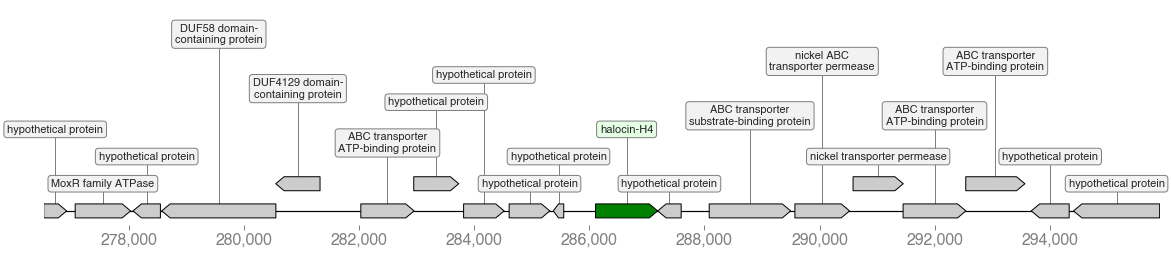

In [165]:
ax = plot_genes(H_mediterranei_context, color_map={'WP_014732703.1': 'green'})

In [69]:
N_hydrolytica_gff = parse_gff(halh4_folder / 'genomes' / 'GCF_004339095.1_ASM433909v1' / 'GCF_004339095.1_ASM433909v1_genomic.gff.gz')
N_hydrolytica_context = get_context(N_hydrolytica_gff, 'WP_132280169.1')
N_hydrolytica_context

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_132280149.1,NZ_SMGQ01000011.1,Protein Homology,CDS,431700,433538,.,+,0,ID=cds-WP_132280149.1;Parent=gene-EDC19_RS0266...,asparagine synthase (glutamine-hydrolyzing)
WP_132280152.1,NZ_SMGQ01000011.1,GeneMarkS-2+,CDS,433603,433992,.,+,0,ID=cds-WP_132280152.1;Parent=gene-EDC19_RS0266...,hypothetical protein
WP_132280155.1,NZ_SMGQ01000011.1,Protein Homology,CDS,434036,435883,.,+,0,ID=cds-WP_132280155.1;Parent=gene-EDC19_RS0267...,TIGR03960 family B12-binding radical SAM protein
WP_132280158.1,NZ_SMGQ01000011.1,Protein Homology,CDS,435873,436556,.,+,0,ID=cds-WP_132280158.1;Parent=gene-EDC19_RS0267...,TIGR03936 family radical SAM-associated protein
WP_132280161.1,NZ_SMGQ01000011.1,Protein Homology,CDS,436572,437798,.,+,0,ID=cds-WP_132280161.1;Parent=gene-EDC19_RS0268...,Rne/Rng family ribonuclease
WP_132280163.1,NZ_SMGQ01000011.1,Protein Homology,CDS,437841,439034,.,+,0,ID=cds-WP_132280163.1;Parent=gene-EDC19_RS0268...,DEAD/DEAH box helicase
WP_132280166.1,NZ_SMGQ01000011.1,GeneMarkS-2+,CDS,440127,440678,.,+,0,ID=cds-WP_132280166.1;Parent=gene-EDC19_RS0269...,hypothetical protein
WP_132280169.1,NZ_SMGQ01000011.1,GeneMarkS-2+,CDS,440744,441955,.,+,0,ID=cds-WP_132280169.1;Parent=gene-EDC19_RS0269...,hypothetical protein
WP_132280172.1,NZ_SMGQ01000011.1,GeneMarkS-2+,CDS,442215,442619,.,-,0,ID=cds-WP_132280172.1;Parent=gene-EDC19_RS0270...,hypothetical protein


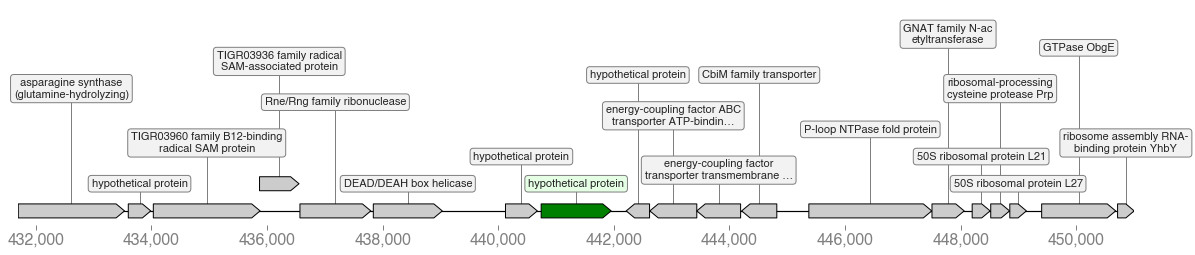

In [70]:
ax = plot_genes(N_hydrolytica_context, color_map={'WP_132280169.1': 'green'})

In [125]:
P_taichungensis_gff = parse_gff(halh4_folder / 'genomes' / 'GCF_013359905.1_ASM1335990v1' / 'GCF_013359905.1_ASM1335990v1_genomic.gff.gz')
P_taichungensis_context = get_context(P_taichungensis_gff, 'WP_175383825.1')
P_taichungensis_context

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_175383819.1,NZ_JABMCC010000121.1,Protein Homology,CDS,736800,737405,.,+,0,ID=cds-WP_175383819.1;Parent=gene-HP548_RS3106...,oxidoreductase
WP_175383820.1,NZ_JABMCC010000121.1,GeneMarkS-2+,CDS,737625,738029,.,+,0,ID=cds-WP_175383820.1;Parent=gene-HP548_RS3106...,hypothetical protein
WP_246318276.1,NZ_JABMCC010000121.1,Protein Homology,CDS,738401,738748,.,+,0,ID=cds-WP_246318276.1;Parent=gene-HP548_RS3107...,SRPBCC domain-containing protein
WP_175384033.1,NZ_JABMCC010000121.1,Protein Homology,CDS,739506,740066,.,+,0,ID=cds-WP_175384033.1;Parent=gene-HP548_RS3108...,YdcF family protein
WP_175383821.1,NZ_JABMCC010000121.1,GeneMarkS-2+,CDS,740303,740965,.,+,0,ID=cds-WP_175383821.1;Parent=gene-HP548_RS3109...,hypothetical protein
WP_175383822.1,NZ_JABMCC010000121.1,Protein Homology,CDS,741190,743979,.,+,0,ID=cds-WP_175383822.1;Parent=gene-HP548_RS3109...,P-loop NTPase fold protein
WP_217504869.1,NZ_JABMCC010000121.1,GeneMarkS-2+,CDS,744113,744358,.,+,0,ID=cds-WP_217504869.1;Parent=gene-HP548_RS3110...,hypothetical protein
WP_246318277.1,NZ_JABMCC010000121.1,GeneMarkS-2+,CDS,744491,744820,.,-,0,ID=cds-WP_246318277.1;Parent=gene-HP548_RS3356...,hypothetical protein
WP_175383823.1,NZ_JABMCC010000121.1,Protein Homology,CDS,745009,745557,.,-,0,ID=cds-WP_175383823.1;Parent=gene-HP548_RS3111...,RNA polymerase sigma factor


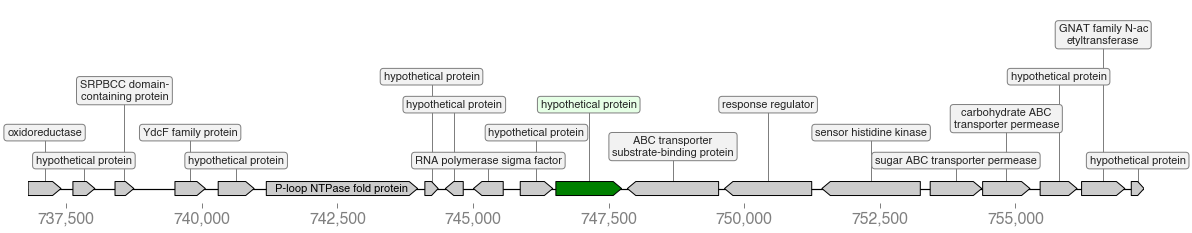

In [126]:
ax = plot_genes(P_taichungensis_context, color_map={'WP_175383825.1': 'green'})

In [127]:
P_amylolyticus_D_gff = parse_gff(halh4_folder / 'genomes' / 'GCF_003719335.1_ASM371933v1' / 'GCF_003719335.1_ASM371933v1_genomic.gff.gz')
P_amylolyticus_D_context = get_context(P_amylolyticus_D_gff, 'WP_123067460.1')
P_amylolyticus_D_context

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
NaN,NZ_RIAS01000036.1,Protein Homology,CDS,1,198,.,+,0,ID=cds-EC604_RS29250;Parent=gene-EC604_RS29250...,ABC transporter substrate-binding protein
WP_123067458.1,NZ_RIAS01000036.1,Protein Homology,CDS,283,1209,.,-,0,ID=cds-WP_123067458.1;Parent=gene-EC604_RS2925...,LysR family transcriptional regulator
WP_123067459.1,NZ_RIAS01000036.1,Protein Homology,CDS,1322,2710,.,+,0,ID=cds-WP_123067459.1;Parent=gene-EC604_RS2926...,MFS transporter
WP_123067460.1,NZ_RIAS01000036.1,GeneMarkS-2+,CDS,3075,4286,.,-,0,ID=cds-WP_123067460.1;Parent=gene-EC604_RS2926...,hypothetical protein
WP_123067461.1,NZ_RIAS01000036.1,GeneMarkS-2+,CDS,4345,4944,.,-,0,ID=cds-WP_123067461.1;Parent=gene-EC604_RS2927...,hypothetical protein
WP_123067462.1,NZ_RIAS01000036.1,Protein Homology,CDS,5233,5799,.,+,0,ID=cds-WP_123067462.1;Parent=gene-EC604_RS2927...,RNA polymerase sigma factor


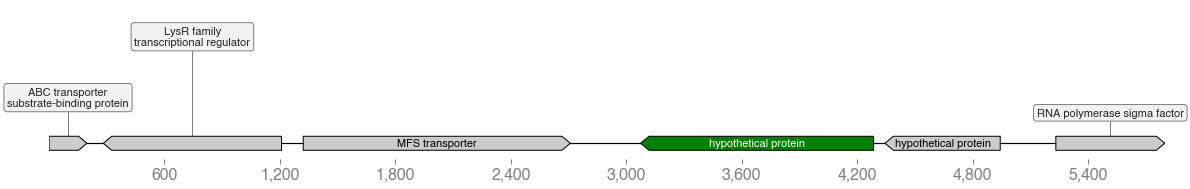

In [128]:
ax = plot_genes(P_amylolyticus_D_context, color_map={'WP_123067460.1': 'green'})

### Homology to Halolysin R4

In [295]:
def parse_domtblout(path):
    return pd.read_csv(
        path, 
        sep='\s+', 
        comment='#', 
        header=None,
        usecols=[0, 3, 6, 7],
        names=[
            'target', 'query', 'evalue', 'bitscore',
        ],
    )

hlyR4_putative_records = []
for assembly_accession in halh4_hits[halh4_hits['domain'] == 'Bacteria']['assembly_accession'].unique():
    folder = (halh4_folder / 'genomes').resolve()
    assert folder.is_dir()

    asm_name = None
    for f in folder.iterdir():
        if assembly_accession in f.name:
            asm_name = f.name
    
    assert asm_name is not None

    pfam_domtblout_file = folder / asm_name / f'{asm_name}_Pfam.domtblout.txt'
    assert pfam_domtblout_file.is_file()

    protein_fasta_file = folder / asm_name / f'{asm_name}_protein.faa.gz'
    assert protein_fasta_file.is_file()

    with gzip.open(protein_fasta_file, 'rt') as f_in:
        records_dict = SeqIO.to_dict(SeqIO.parse(f_in, 'fasta'))

    df = parse_domtblout(pfam_domtblout_file).set_index('query')

    protein_ids = df.loc['Peptidase_S8', 'target'].unique()

    print(assembly_accession, gtdb_species, len(protein_ids))

    gtdb_species = gtdb_metadata.loc[assembly_accession, 'gtdb_species']
    for protein_id in protein_ids:
        record = records_dict[protein_id]
        record.id = f'{protein_id}@{assembly_accession}'
        record.name = ''
        record.description = f'Peptidase_S8 [{gtdb_species}]'
        hlyR4_putative_records.append(record)

with (halh4_out / 'putative_hlyR4_homologs.fasta').open('w') as f_out:
    SeqIO.write(hlyR4_putative_records, f_out, 'fasta')
    

GCF_001955925.1 Paenibacillus taichungensis 6
GCF_003719335.1 Paenibacillus sp001955925 6
GCF_004339095.1 Paenibacillus amylolyticus D 11
GCF_013359905.1 Natranaerovirga hydrolytica 5


In [291]:
def parse_tblout(path):
    return pd.read_csv(
        path, 
        sep='\s+', 
        comment='#', 
        header=None,
        usecols=[0, 2, 4, 5],
        names=[
            'target', 'query', 'evalue', 'bitscore',
        ],
    )

putative_hlyR4_df = parse_tblout(halh4_folder / 'putative_hlyR4_homologs.tblout.txt')

putative_hlyR4_df['target_accession'] = putative_hlyR4_df['target'].apply(lambda v: v.split('@')[1])
putative_hlyR4_df['target_protein_id'] = putative_hlyR4_df['target'].apply(lambda v: v.split('@')[0])

putative_hlyR4_df = pd.merge(
    putative_hlyR4_df,
    gtdb_metadata.reset_index()[
        ['assembly_accession', 'domain', 'gtdb_phylum', 'gtdb_class', 'gtdb_order', 'gtdb_family', 'gtdb_genus', 'gtdb_species']
    ].rename(columns={'assembly_accession': 'target_accession'}),
    on='target_accession',
    how='left',
).drop(columns=['query']).set_index('target_accession')

putative_hlyR4_df

,target,evalue,bitscore,target_protein_id,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species
target_accession,,,,,,,,,,,
GCF_013359905.1,WP_175382407.1@GCF_013359905.1,7.700000e-58,187.6,WP_175382407.1,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus taichungensis
GCF_003719335.1,WP_123065789.1@GCF_003719335.1,1.600000e-57,186.5,WP_123065789.1,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus amylolyticus D
GCF_013359905.1,WP_076288104.1@GCF_013359905.1,6.600000e-56,181.2,WP_076288104.1,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus taichungensis
GCF_003719335.1,WP_123062554.1@GCF_003719335.1,1.300000e-55,180.3,WP_123062554.1,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus amylolyticus D
GCF_001955925.1,WP_036690263.1@GCF_001955925.1,1.500000e-53,173.4,WP_036690263.1,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus sp001955925
GCF_013359905.1,WP_076292189.1@GCF_013359905.1,3.900000e-49,158.9,WP_076292189.1,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus taichungensis
GCF_003719335.1,WP_123067148.1@GCF_003719335.1,2.600000e-48,156.1,WP_123067148.1,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus amylolyticus D
GCF_001955925.1,WP_083678229.1@GCF_001955925.1,1.000000e-46,150.9,WP_083678229.1,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus sp001955925
GCF_001955925.1,WP_083678081.1@GCF_001955925.1,1.300000e-34,111.0,WP_083678081.1,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus sp001955925


In [296]:
putative_hlyR4_df['gtdb_species'].value_counts()

Paenibacillus amylolyticus D    5
Paenibacillus sp001955925       5
Paenibacillus taichungensis     4
Natranaerovirga hydrolytica     1
Name: gtdb_species, dtype: int64

In [292]:
hlyR4_targets = putative_hlyR4_df.sort_values(['domain', 'gtdb_species', 'target'])['target'].unique()

hlyR4_records = []
for target in hlyR4_targets:
    protein_id = target.split('@')[0]
    assembly_accession = target.split('@')[1]

    folder = halh4_folder / 'genomes'
    assert folder.is_dir()

    asm_name = None
    for f in folder.iterdir():
        if assembly_accession in f.name:
            asm_name = f.name
    
    assert asm_name is not None

    protein_fasta_file = folder / asm_name / f'{asm_name}_protein.faa.gz'
    assert protein_fasta_file.is_file()

    with gzip.open(protein_fasta_file, 'rt') as f_in:
        records_dict = SeqIO.to_dict(SeqIO.parse(f_in, 'fasta'))

    record = records_dict[protein_id]
    record.id = f'{protein_id}@{assembly_accession}'
    record.name = ''
    record.description = gtdb_metadata.loc[assembly_accession, 'gtdb_species']
    hlyR4_records.append(record)

with (halh4_out / 'hlyR4_homologs.fasta').open('w') as f_out:
    SeqIO.write(hlyR4_records, f_out, 'fasta')

In [293]:
hlyR4_sp = pd.read_csv(halh4_folder / 'hlyR4_signalp-6' / 'prediction_results.txt', sep='\t')

hlyR4_sp['assembly_accession'] = hlyR4_sp['ID'].apply(lambda v: v.split('@')[1].split(' ')[0])
hlyR4_sp['protein_id'] = hlyR4_sp['ID'].apply(lambda v: v.split('@')[0])

hlyR4_sp = pd.merge(
    hlyR4_sp[['ID', 'assembly_accession', 'protein_id', 'Prediction', 'CS Position']],
    gtdb_metadata.reset_index()[['assembly_accession', 'domain', 'gtdb_genus', 'gtdb_species']],
    on='assembly_accession',
    how='left',
)
hlyR4_sp[hlyR4_sp['Prediction'] != 'OTHER']

,ID,assembly_accession,protein_id,Prediction,CS Position,domain,gtdb_genus,gtdb_species
7,WP_123064576.1@GCF_003719335.1 Peptidase_S8 [P...,GCF_003719335.1,WP_123064576.1,SP,CS pos: 25-26. Pr: 0.9815,Bacteria,Paenibacillus,Paenibacillus amylolyticus D
9,WP_123063612.1@GCF_003719335.1 Peptidase_S8 [P...,GCF_003719335.1,WP_123063612.1,SP,CS pos: 29-30. Pr: 0.9758,Bacteria,Paenibacillus,Paenibacillus amylolyticus D
24,WP_281364809.1@GCF_013359905.1 Peptidase_S8 [P...,GCF_013359905.1,WP_281364809.1,SP,CS pos: 25-26. Pr: 0.9656,Bacteria,Paenibacillus,Paenibacillus taichungensis
27,WP_175382701.1@GCF_013359905.1 Peptidase_S8 [P...,GCF_013359905.1,WP_175382701.1,SP,CS pos: 29-30. Pr: 0.9774,Bacteria,Paenibacillus,Paenibacillus taichungensis


In [294]:
putative_hlyR4_df[putative_hlyR4_df['target_protein_id'].isin(hlyR4_sp[hlyR4_sp['Prediction'] != 'OTHER']['protein_id'].values)]

,target,evalue,bitscore,target_protein_id,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species
target_accession,,,,,,,,,,,
GCF_003719335.1,WP_123064576.1@GCF_003719335.1,2.900000e-20,63.6,WP_123064576.1,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus amylolyticus D
GCF_013359905.1,WP_281364809.1@GCF_013359905.1,1.000000e-19,61.9,WP_281364809.1,Bacteria,Bacillota,Bacilli,Paenibacillales,Paenibacillaceae,Paenibacillus,Paenibacillus taichungensis


## Tree annotations

In [82]:
itol_labels(
    [
        (protein_id.replace('@', '_'), gtdb_metadata.loc[protein_id.split('@')[1], 'gtdb_species'])
        for protein_id in halh4_hits.index
    ],
    halh4_out / 'tree' / 'annot_labels.txt'
)

## Gene context

In [184]:
halh4_data_to_plot = [
    ('GCF_000306765.2', 'WP_014732703.1'),        # Haloferax mediterranei
    ('GCF_000337535.1', 'WP_241433888.1'),        # Natrialba aegyptia
    ('GCF_023093535.1', 'WP_247730522.1'),        # Halovivax limisalsi
    ('GCF_019633745.1', 'WP_220681389.1'),        # Methanofollis formosanus
    ('GCF_000970305.1', 'WP_155396796.1'),        # Methanosarcina barkeri A
    ('GCA_944320495.1', 'CALUHR010000006.1_67'),  # UBA71 sp944320495
    ('GCA_023402275.1', 'JAEXCH010000014.1_14'),  # Methanoplasma sp023402275
    ('GCF_001955925.1', 'WP_076157611.1'),        # Paenibacillus sp001955925
    ('GCF_004339095.1', 'WP_132280169.1'),        # Natranaerovirga hydrolytica
    ('GCF_013359905.1', 'WP_175383825.1'),        # Paenibacillus taichungensis
    ('GCF_003719335.1', 'WP_123067460.1'),        # Paenibacillus amylolyticus D
]

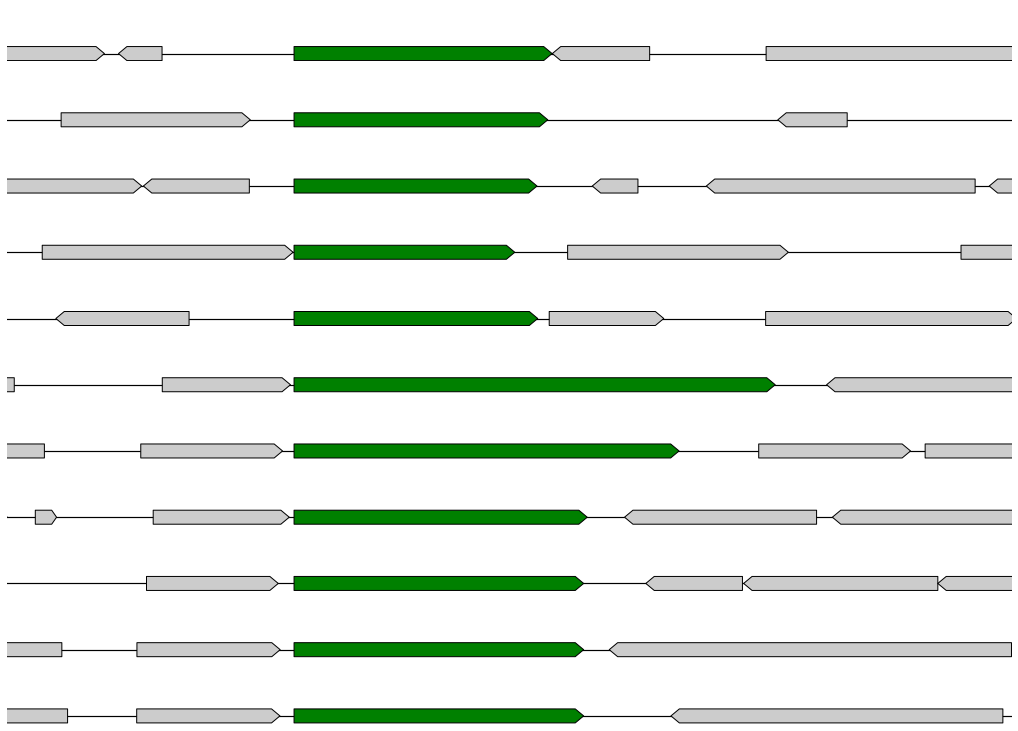

In [188]:
n_rows = len(halh4_data_to_plot)
fig, axes = plt.subplots(n_rows, 1, figsize=(18, 1.2 * len(halh4_data_to_plot)))

upstream = 4_000
downstream = 4_000
max_display_length_left = 1_200
max_display_length_right = 3_000

lengths = []
gene_contexts = {}
for i, (accession, core_protein_id) in enumerate(halh4_data_to_plot):
    ax = axes[i]
    gtdb_species = gtdb_metadata.loc[accession, 'gtdb_species']

    folder = halh4_folder / 'genomes'
    assert folder.is_dir()

    asm_name = None
    for f in folder.iterdir():
        if accession in f.name:
            asm_name = f.name
    
    assert asm_name is not None

    gff_file = folder / asm_name / f'{asm_name}_genomic.gff.gz'
    assert gff_file.is_file()

    gff = parse_gff(gff_file)

    strand = gff.loc[core_protein_id, 'strand']

    gene_context = get_context(
        gff, 
        core_protein_id, 
        n_upstream=upstream if strand == '+' else downstream,
        n_downstream=downstream if strand == '+' else upstream,
    )

    gene_contexts[accession] = gene_context

    if strand == '-':
        # Swap strand
        df = gene_context.reset_index()
        contig_length = df['end'].max()
        old_start = df['start'].copy()
        old_end = df['end'].copy()

        df['start'] = contig_length - old_end + 1
        df['end'] = contig_length - old_start + 1

        df['strand'] = df['strand'].map({'+': '-', '-': '+'})

        # Re-order genes by their new start position
        gene_context = df.sort_values(by='start').reset_index(drop=True).set_index('protein_id')

    ax = plot_genes(gene_context, ax=ax, no_labels=True, color_map={core_protein_id: 'green'});

    left = gene_context.loc[core_protein_id, 'start'] - max_display_length_left
    right = gene_context.loc[core_protein_id, 'start'] + max_display_length_right
    ax.set_xlim(left, right)
    ax.get_xaxis().set_visible(False)

fig.savefig(halh4_out / 'gene_synteny.pdf', dpi=300, bbox_inches='tight')

In [205]:
subset_with_conserved_protein = (
    ('GCA_944320495.1', 'CALUHR010000006.1_67'),  # UBA71 sp944320495
    ('GCA_023402275.1', 'JAEXCH010000014.1_14'),  # Methanoplasma sp023402275
    ('GCF_001955925.1', 'WP_076157611.1'),        # Paenibacillus sp001955925
    ('GCF_004339095.1', 'WP_132280169.1'),        # Natranaerovirga hydrolytica
    ('GCF_013359905.1', 'WP_175383825.1'),        # Paenibacillus taichungensis
    ('GCF_003719335.1', 'WP_123067460.1'),        # Paenibacillus amylolyticus D
)

records = []
for assembly_accession, core_protein_id in subset_with_conserved_protein:
    context = gene_contexts[assembly_accession].reset_index()

    row = context[context['protein_id'] == core_protein_id].iloc[0]
    if row['strand'] == '+':
        conserved_protein_id = context.loc[row.name - 1, 'protein_id']
    elif row['strand'] == '-':
        conserved_protein_id = context.loc[row.name + 1, 'protein_id']
    else:
        raise ValueError(row['strand'])

    folder = halh4_folder / 'genomes'
    assert folder.is_dir()

    asm_name = None
    for f in folder.iterdir():
        if assembly_accession in f.name:
            asm_name = f.name
    
    assert asm_name is not None

    protein_fasta_file = folder / asm_name / f'{asm_name}_protein.faa.gz'
    assert protein_fasta_file.is_file()

    with gzip.open(protein_fasta_file, 'rt') as f_in:
        records_dict = SeqIO.to_dict(SeqIO.parse(f_in, 'fasta'))

    record = records_dict[conserved_protein_id]
    if record.seq[-1] == '*':
        record.seq = record.seq[:-1]

    records.append(record)

with (halh4_out / 'halH4_upstream.fasta').open('w') as f_out:
    SeqIO.write(records, f_out, 'fasta')


### SignalP

In [237]:
signalp_predictions = pd.read_csv(halh4_folder / 'signalp-6' / 'prediction_results.txt', sep='\t')
signalp_predictions['assembly_accession'] = signalp_predictions['ID'].apply(lambda v: v.split('@')[1])

signalp_predictions = pd.merge(
    signalp_predictions[['ID', 'assembly_accession', 'Prediction', 'CS Position']],
    gtdb_metadata.reset_index()[['assembly_accession', 'domain', 'gtdb_genus', 'gtdb_species']],
    on='assembly_accession',
    how='left',
)
signalp_predictions[
    (signalp_predictions['domain'] == 'Bacteria') |
    (signalp_predictions['gtdb_genus'].isin(['Haloferax', 'UBA71', 'Methanoplasma']))
]

,ID,assembly_accession,Prediction,CS Position,domain,gtdb_genus,gtdb_species
0,WP_014732703.1@GCF_000306765.2,GCF_000306765.2,TAT,CS pos: 37-38. Pr: 0.9047,Archaea,Haloferax,Haloferax mediterranei
5,WP_076157611.1@GCF_001955925.1,GCF_001955925.1,SP,CS pos: 30-31. Pr: 0.9754,Bacteria,Paenibacillus,Paenibacillus sp001955925
9,JAEXCH010000014.1_14@GCA_023402275.1,GCA_023402275.1,OTHER,NaN,Archaea,Methanoplasma,Methanoplasma sp023402275
13,WP_123067460.1@GCF_003719335.1,GCF_003719335.1,SP,CS pos: 33-34. Pr: 0.9630,Bacteria,Paenibacillus,Paenibacillus amylolyticus D
15,WP_132280169.1@GCF_004339095.1,GCF_004339095.1,SP,CS pos: 32-33. Pr: 0.9622,Bacteria,Natranaerovirga,Natranaerovirga hydrolytica
16,WP_175383825.1@GCF_013359905.1,GCF_013359905.1,SP,CS pos: 33-34. Pr: 0.9593,Bacteria,Paenibacillus,Paenibacillus taichungensis
20,CALUHR010000006.1_67@GCA_944320495.1,GCA_944320495.1,SP,CS pos: 27-28. Pr: 0.9578,Archaea,UBA71,UBA71 sp944320495


SIgnalP-6 does not detect a signal peptide for _Methanoplasma sp023402275_, while SignalP-5 does (Sec).

### Extract halH4 sequences without signal peptide

In [241]:
no_signal_records = []
for _, row in signalp_predictions[
    (signalp_predictions['gtdb_genus'].isin(['Haloferax'])) |
    (signalp_predictions['domain'] == 'Bacteria')
].iterrows():
    assembly_accession = row['assembly_accession']
    protein_id = row['ID'].split('@')[0]

    if row['gtdb_genus'] == 'Haloferax':
        cleavage_start = 45
    else:
        cleavage_start = int(re.match(r'^CS pos: ([0-9]+)-[0-9]+\. .+$', row['CS Position'])[1])

    folder = halh4_folder / 'genomes'
    assert folder.is_dir()

    asm_name = None
    for f in folder.iterdir():
        if assembly_accession in f.name:
            asm_name = f.name
    
    assert asm_name is not None

    protein_fasta_file = folder / asm_name / f'{asm_name}_protein.faa.gz'
    assert protein_fasta_file.is_file()

    with gzip.open(protein_fasta_file, 'rt') as f_in:
        records_dict = SeqIO.to_dict(SeqIO.parse(f_in, 'fasta'))

    record = records_dict[protein_id]
    record.id = f'{protein_id}@{assembly_accession}'
    record.seq = record.seq[cleavage_start:]

    no_signal_records.append(record)

with (halh4_out / 'halH4_no_signal.fasta').open('w') as f_out:
    SeqIO.write(no_signal_records, f_out, 'fasta')